<a href="https://colab.research.google.com/github/mrjoshceo/JobShield-AI/blob/main/Fraudulent_Job_Detection_SVM_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning-Based Detection of Fraudulent Online Job Listings

## Phase 1 – Dataset Selection and Exploration

The objective of this phase is to explore the fake job postings dataset by examining its structure, data quality, and class distribution to inform the preprocessing and feature selection stages.

Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


– Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

:Load the Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dissertation/Dataset/fake_job_postings.csv')

Display the First Five Records

In [ ]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


Check Dataset Dimensions

In [ ]:
df.shape

(17880, 18)

Display Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

Display Column Names

In [ ]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

Analyse Missing Values

In [ ]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


Check for Duplicate Records

In [ ]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

Analyse Class Distribution

In [ ]:
# Count the number of genuine and fraudulent job postings
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


Visualise Class Distribution

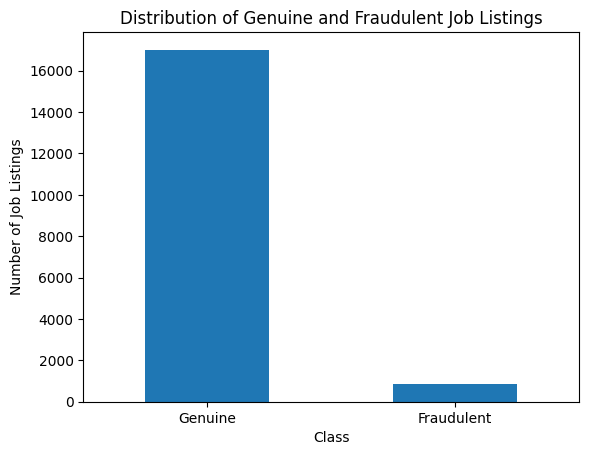

In [ ]:
import matplotlib.pyplot as plt

# Plot class distribution
df['fraudulent'].value_counts().plot(kind='bar')

plt.title("Distribution of Genuine and Fraudulent Job Listings")
plt.xlabel("Class")
plt.ylabel("Number of Job Listings")
plt.xticks([0, 1], ["Genuine", "Fraudulent"], rotation=0)

plt.show()

#Phase 2 – Data Preprocessing

### Objective

The objective of this phase is to prepare the dataset for machine learning through data cleaning, feature selection, text transformation, and data preparation for model training and evaluation.

Review Dataset Features

In [ ]:
# Display all column names as a list
list(df.columns)

['job_id',
 'title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent']

Select Relevant Features

In [ ]:
# Select the features to be used for machine learning
selected_columns = [
    'title',
    'location',
    'department',
    'salary_range',
    'company_profile',
    'description',
    'requirements',
    'benefits',
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function',
    'fraudulent'
]

df_selected = df[selected_columns]

Verify Selected Features

In [ ]:
# Display the selected columns
df_selected.columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

Handle Missing Values

In [ ]:
# Replace missing values in text columns with empty strings

text_columns = [
    'title',
    'location',
    'department',
    'salary_range',
    'company_profile',
    'description',
    'requirements',
    'benefits',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function'
]

df_selected = df_selected.copy()

df_selected.loc[:, text_columns] = df_selected[text_columns].fillna("")

Combine Text Features

In [ ]:
# Combine all text columns into one feature

df_selected["combined_text"] = (
    df_selected["title"] + " " +
    df_selected["location"] + " " +
    df_selected["department"] + " " +
    df_selected["salary_range"] + " " +
    df_selected["company_profile"] + " " +
    df_selected["description"] + " " +
    df_selected["requirements"] + " " +
    df_selected["benefits"] + " " +
    df_selected["employment_type"] + " " +
    df_selected["required_experience"] + " " +
    df_selected["required_education"] + " " +
    df_selected["industry"] + " " +
    df_selected["function"]
)

Verify Combined Text

In [ ]:
# Display the combined text for the first five records

df_selected[["combined_text"]].head()

,combined_text
0,"Marketing Intern US, NY, New York Marketing W..."
1,"Customer Service - Cloud Video Production NZ, ..."
2,"Commissioning Machinery Assistant (CMA) US, IA..."
3,"Account Executive - Washington DC US, DC, Wash..."
4,"Bill Review Manager US, FL, Fort Worth SpotS..."


#Phase 3 – Feature Engineering

### Objective

The objective of this phase is to split the dataset and convert textual job listings into numerical features using TF-IDF.

Separate Features and Target Variable

In [ ]:
# Separate input features (X) and target variable (y)

X = df_selected["combined_text"]
y = df_selected["fraudulent"]

Verify Features and Target

In [ ]:
# Display the first five text records

X.head()

,combined_text
0,"Marketing Intern US, NY, New York Marketing W..."
1,"Customer Service - Cloud Video Production NZ, ..."
2,"Commissioning Machinery Assistant (CMA) US, IA..."
3,"Account Executive - Washington DC US, DC, Wash..."
4,"Bill Review Manager US, FL, Fort Worth SpotS..."


In [ ]:
# Display the first five target values

y.head()

,fraudulent
0,0
1,0
2,0
3,0
4,0


Split Dataset into Training and Testing Sets

In [ ]:
# Import train-test split

from sklearn.model_selection import train_test_split

In [ ]:
# Split the dataset into training (80%) and testing (20%)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Verify Training and Testing Sets

In [ ]:
# Display the size of each dataset

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14304
Testing samples: 3576


Import TF-IDF Vectorizer

In [ ]:
# Import TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

Create TF-IDF Vectorizer

In [ ]:
# Create TF-IDF Vectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

Apply TF-IDF Vectorization

In [ ]:
# Fit TF-IDF on the training data and transform both datasets

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Verify TF-IDF Output

In [ ]:
# Display the shape of the TF-IDF matrices

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (14304, 5000)
Testing TF-IDF Shape: (3576, 5000)


## Apply SMOTE

Balance the training data using SMOTE while keeping the test data unchanged.

In [ ]:
# Import SMOTE
from imblearn.over_sampling import SMOTE

# Display the original class distribution
print("Class Distribution Before Applying SMOTE")
print(y_train.value_counts())

# Apply SMOTE to the training data only
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_tfidf,
    y_train
)

# Display the balanced class distribution
print("\nClass Distribution After Applying SMOTE")
print(y_train_smote.value_counts())

# Display the dataset shapes
print("\nOriginal Training Shape:", X_train_tfidf.shape)
print("Balanced Training Shape:", X_train_smote.shape)

Class Distribution Before Applying SMOTE
fraudulent
0    13611
1      693
Name: count, dtype: int64

Class Distribution After Applying SMOTE
fraudulent
0    13611
1    13611
Name: count, dtype: int64

Original Training Shape: (14304, 5000)
Balanced Training Shape: (27222, 5000)


# Phase 4 – Machine Learning Model Development

This phase trains and evaluates machine learning models for fraud detection, using Logistic Regression as the baseline model.

## Model 1 – Logistic Regression

Train and evaluate the Logistic Regression model using the SMOTE-balanced training data.

### Import Logistic Regression Library

In [ ]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

Create the Logistic Regression Model

In [ ]:
# Create Logistic Regression model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

### Train the Logistic Regression Model

Train the model using the SMOTE-balanced training data.

In [ ]:
# Train the Logistic Regression model
lr_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

### Make Predictions

The trained Logistic Regression model is used to predict the class of job listings in the testing dataset.

In [ ]:
# Predict the class labels for the testing dataset
y_pred_lr = lr_model.predict(X_test_tfidf)

### Verify the First Ten Predictions

The first ten predictions are displayed to confirm successful model predictions.

In [ ]:
# Display the first ten predicted class labels
y_pred_lr[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Classification Report

Precision, Recall, and F1-score are calculated to evaluate the model's ability to accurately identify fraudulent job listings.

In [ ]:
# Import classification metrics
from sklearn.metrics import classification_report

In [ ]:
# Display the classification report
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Genuine", "Fraudulent"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      3403
  Fraudulent       0.75      0.88      0.81       173

    accuracy                           0.98      3576
   macro avg       0.87      0.93      0.90      3576
weighted avg       0.98      0.98      0.98      3576



### Generate the Confusion Matrix

A confusion matrix is generated to compare the predicted and actual class labels, providing a summary of the model's classification performance.

In [ ]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

In [ ]:
# Generate the confusion matrix
lr_cm = confusion_matrix(y_test, y_pred_lr)

print(lr_cm)

[[3352   51]
 [  20  153]]


### Visualise the Confusion Matrix

The confusion matrix is visualised using a heatmap.

In [ ]:
# Import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

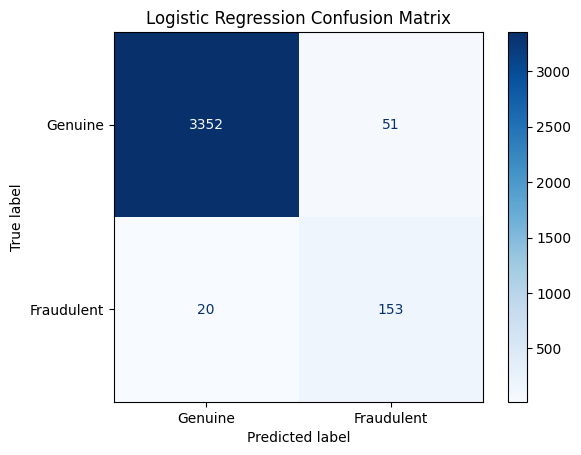

In [ ]:
# Plot the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_tfidf,
    y_test,
    display_labels=["Genuine", "Fraudulent"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Calculate the ROC-AUC Score

The ROC-AUC score is calculated to evaluate the model's ability to distinguish between genuine and fraudulent job listings.

In [ ]:
# Import ROC-AUC metric

from sklearn.metrics import roc_auc_score

In [ ]:
# Generate prediction probabilities for the positive class (Fraudulent)

y_prob_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
# Calculate the ROC-AUC Score

lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression ROC-AUC Score:", round(lr_auc, 4))

Logistic Regression ROC-AUC Score: 0.9885


### Calculate Model Accuracy

The accuracy score is reported as a supporting evaluation metric, indicating the overall percentage of correctly classified job listings.

In [ ]:
# Import accuracy metric
from sklearn.metrics import accuracy_score

In [ ]:
# Calculate the model accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))

Logistic Regression Accuracy: 0.9801


## Model 2 – Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve classification performance.

### Model 2 – Random Forest Classifier

Train and evaluate the Random Forest model using the SMOTE-balanced training data.

In [ ]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

### Create the Random Forest Model

Create the Random Forest model with 100 decision trees.

In [ ]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

### Train the Random Forest Model

Train the model using the SMOTE-balanced training data.

In [ ]:
# Train the Random Forest model
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

### Make Predictions

Predict the class labels for the testing dataset.

In [ ]:
# Predict the class labels for the testing dataset
y_pred_rf = rf_model.predict(X_test_tfidf)

### Verify the First Ten Predictions

Display the first ten predicted class labels.

In [ ]:
# Display the first ten predicted class labels
y_pred_rf[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Classification Report

Display Precision, Recall and F1-score for genuine and fraudulent job listings.

In [ ]:
# Import classification metrics
from sklearn.metrics import classification_report

In [ ]:
# Display the classification report
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Genuine", "Fraudulent"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       0.98      1.00      0.99      3403
  Fraudulent       0.98      0.65      0.78       173

    accuracy                           0.98      3576
   macro avg       0.98      0.83      0.89      3576
weighted avg       0.98      0.98      0.98      3576



### Generate the Confusion Matrix

Generate the confusion matrix for the Random Forest model.

In [ ]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

In [ ]:
# Generate the confusion matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)

print(rf_cm)

[[3401    2]
 [  60  113]]


### Visualise the Confusion Matrix

Visualise the confusion matrix using a heatmap.

In [ ]:
# Import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

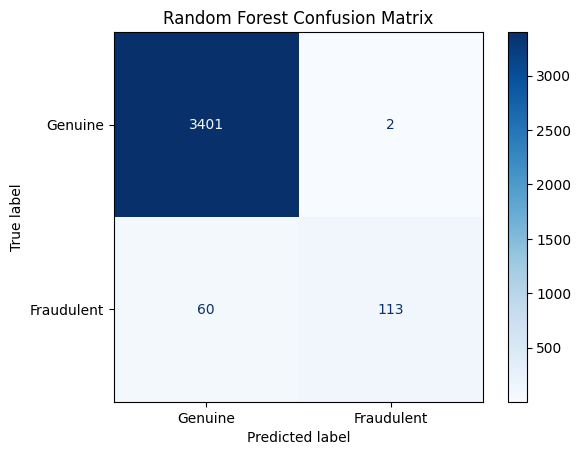

In [ ]:
# Plot the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test_tfidf,
    y_test,
    display_labels=["Genuine", "Fraudulent"],
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

### Calculate the ROC-AUC Score

Calculate the ROC-AUC score for the Random Forest model.

In [ ]:
# Import ROC-AUC metric
from sklearn.metrics import roc_auc_score

In [ ]:
# Generate prediction probabilities for the positive class
y_prob_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
# Calculate the ROC-AUC score
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC Score:", round(rf_auc, 4))

Random Forest ROC-AUC Score: 0.9916


### Calculate Model Accuracy

Report overall accuracy as a supporting evaluation metric.

In [ ]:
# Import accuracy metric
from sklearn.metrics import accuracy_score

In [ ]:
# Calculate the model accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.9827


## Model 3 – Naive Bayes

Train and evaluate the Naive Bayes model using the SMOTE-balanced training data.

### Import Naive Bayes Library

Import the Multinomial Naive Bayes classifier.

In [ ]:
# Import Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

### Create the Naive Bayes Model

Create the Naive Bayes classifier.

In [ ]:
# Create Naive Bayes model
nb_model = MultinomialNB()

### Train the Naive Bayes Model

Train the model using the SMOTE-balanced training data.

In [ ]:
# Train the Naive Bayes model
nb_model.fit(X_train_smote, y_train_smote)

MultinomialNB()

### Make Predictions

Predict the class of job listings in the testing dataset.

In [ ]:
# Predict the class labels for the testing dataset
y_pred_nb = nb_model.predict(X_test_tfidf)

### Verify the First Ten Predictions

Display the first ten predictions to confirm successful model predictions.

In [ ]:
# Display the first ten predicted class labels
y_pred_nb[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Classification Report

Display Precision, Recall and F1-score for genuine and fraudulent job listings.

In [ ]:
# Import classification metrics
from sklearn.metrics import classification_report

In [ ]:
# Display the classification report
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Genuine", "Fraudulent"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       0.99      0.94      0.97      3403
  Fraudulent       0.44      0.88      0.59       173

    accuracy                           0.94      3576
   macro avg       0.72      0.91      0.78      3576
weighted avg       0.97      0.94      0.95      3576



### Generate the Confusion Matrix

Generate a confusion matrix to summarise the model's classification performance.

In [ ]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

In [ ]:
# Generate the confusion matrix
nb_cm = confusion_matrix(
    y_test,
    y_pred_nb
)

print(nb_cm)

[[3212  191]
 [  21  152]]


### Visualise the Confusion Matrix

Visualise the confusion matrix using a heatmap.

In [ ]:
# Import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

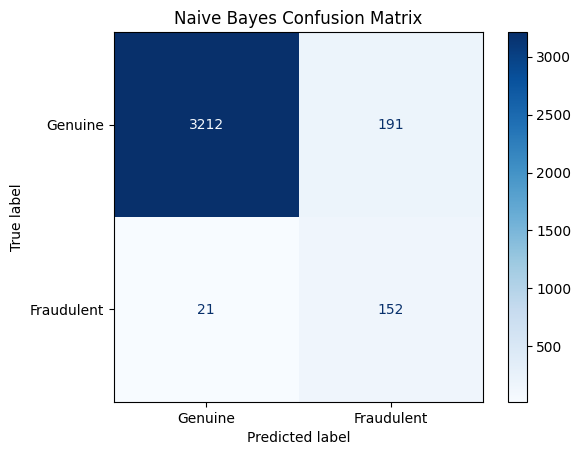

In [ ]:
# Plot the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test_tfidf,
    y_test,
    display_labels=["Genuine", "Fraudulent"],
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")
plt.show()

### Calculate the ROC-AUC Score

Evaluate the model's ability to distinguish between genuine and fraudulent job listings.

In [ ]:
# Import ROC-AUC metric
from sklearn.metrics import roc_auc_score

In [ ]:
# Generate prediction probabilities for the positive class
y_prob_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
# Calculate the ROC-AUC score
nb_auc = roc_auc_score(
    y_test,
    y_prob_nb
)

print("Naive Bayes ROC-AUC Score:", round(nb_auc, 4))

Naive Bayes ROC-AUC Score: 0.9808


### Calculate Model Accuracy

Report overall accuracy as a supporting evaluation metric.

In [ ]:
# Import accuracy metric
from sklearn.metrics import accuracy_score

In [ ]:
# Calculate the model accuracy
nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

print("Naive Bayes Accuracy:", round(nb_accuracy, 4))

Naive Bayes Accuracy: 0.9407


## Model 4 – Support Vector Machine (SVM)

Train and evaluate the Support Vector Machine (SVM) model using the SMOTE-balanced training data.

### Import SVM Library

Import the Support Vector Machine classifier.

In [ ]:
# Import Support Vector Machine
from sklearn.svm import SVC

### Create the SVM Model

Create the Support Vector Machine classifier.

In [ ]:
# Create SVM model
svm_model = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

### Train the SVM Model

Train the model using the SMOTE-balanced training data.

In [ ]:
# Train the SVM model
svm_model.fit(X_train_smote, y_train_smote)

SVC(kernel='linear', probability=True, random_state=42)

### Make Predictions

Predict the class of job listings in the testing dataset.

In [ ]:
# Predict the class labels for the testing dataset
y_pred_svm = svm_model.predict(X_test_tfidf)

### Verify the First Ten Predictions

Display the first ten predictions to confirm successful model predictions.

In [ ]:
# Display the first ten predicted class labels
y_pred_svm[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Classification Report

Display Precision, Recall and F1-score for genuine and fraudulent job listings.

In [ ]:
# Import classification metrics
from sklearn.metrics import classification_report

In [ ]:
# Display the classification report
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Genuine", "Fraudulent"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      3403
  Fraudulent       0.83      0.83      0.83       173

    accuracy                           0.98      3576
   macro avg       0.91      0.91      0.91      3576
weighted avg       0.98      0.98      0.98      3576



### Generate the Confusion Matrix

Generate a confusion matrix to summarise the model's classification performance.

In [ ]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

In [ ]:
# Generate the confusion matrix
svm_cm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(svm_cm)

[[3374   29]
 [  29  144]]


### Visualise the Confusion Matrix

Visualise the confusion matrix using a heatmap.

In [ ]:
# Import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

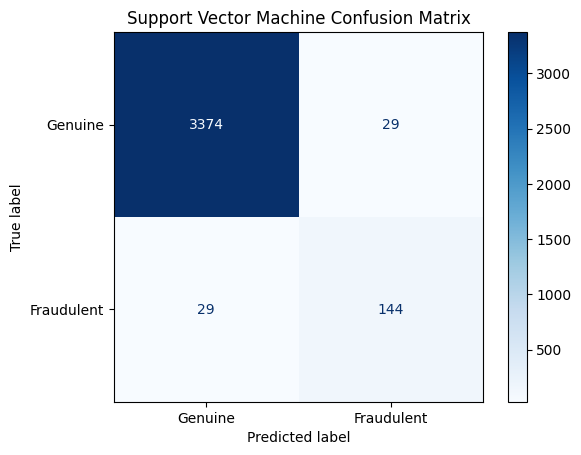

In [ ]:
# Plot the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test_tfidf,
    y_test,
    display_labels=["Genuine", "Fraudulent"],
    cmap="Blues"
)

plt.title("Support Vector Machine Confusion Matrix")
plt.show()

### Calculate the ROC-AUC Score

Evaluate the model's ability to distinguish between genuine and fraudulent job listings.

In [ ]:
# Import ROC-AUC metric
from sklearn.metrics import roc_auc_score

In [ ]:
# Generate prediction probabilities for the positive class
y_prob_svm = svm_model.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
# Calculate the ROC-AUC score
svm_auc = roc_auc_score(
    y_test,
    y_prob_svm
)

print("Support Vector Machine ROC-AUC Score:", round(svm_auc, 4))

Support Vector Machine ROC-AUC Score: 0.9877


### Calculate Model Accuracy

Report overall accuracy as a supporting evaluation metric.

In [ ]:
# Import accuracy metric
from sklearn.metrics import accuracy_score

In [ ]:
# Calculate the model accuracy
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("Support Vector Machine Accuracy:", round(svm_accuracy, 4))

Support Vector Machine Accuracy: 0.9838


# Phase 5 – Model Comparison and Selection

The four machine learning models are compared to select the best-performing model for deployment.

### Model Performance Comparison

Compare the performance of all machine learning models trained using the SMOTE-balanced dataset. The models are primarily evaluated using the Fraudulent F1-score, with Precision, Recall, Accuracy and ROC-AUC used as supporting metrics.

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Naive Bayes",
        "Support Vector Machine"
    ],

    "Accuracy": [

        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)

    ],

    "Fraud Precision": [

        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm)

    ],

    "Fraud Recall": [

        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm)

    ],

    "Fraud F1-Score": [

        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm)

    ],

    "ROC-AUC": [

        lr_auc,
        rf_auc,
        nb_auc,
        svm_auc

    ]

})

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Fraud Precision,Fraud Recall,Fraud F1-Score,ROC-AUC
0,Logistic Regression,0.9801,0.7500,0.8844,0.8117,0.9885
1,Random Forest,0.9827,0.9826,0.6532,0.7847,0.9916
2,Naive Bayes,0.9407,0.4431,0.8786,0.5891,0.9808
3,Support Vector Machine,0.9838,0.8324,0.8324,0.8324,0.9877


### Rank the Models

Rank the machine learning models using the Fraudulent F1-score as the primary evaluation metric.

In [ ]:
comparison_df = comparison_df.sort_values(
    by="Fraud F1-Score",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Fraud Precision,Fraud Recall,Fraud F1-Score,ROC-AUC
0,Support Vector Machine,0.9838,0.8324,0.8324,0.8324,0.9877
1,Logistic Regression,0.9801,0.7500,0.8844,0.8117,0.9885
2,Random Forest,0.9827,0.9826,0.6532,0.7847,0.9916
3,Naive Bayes,0.9407,0.4431,0.8786,0.5891,0.9808


The Support Vector Machine (SVM) was selected as the final model because it achieved the highest Fraudulent F1-score after training with the SMOTE-balanced dataset. It also provided a strong balance between Precision and Recall while maintaining excellent overall classification performance.

## Select the Best Model

Identify and select the final machine learning model based on the highest Fraudulent F1-score after training with the SMOTE-balanced dataset.

In [ ]:
# Select the best-performing model
best_model = comparison_df.iloc[0]

print("Selected Model:", best_model["Model"])
print("Fraud F1-Score:", round(best_model["Fraud F1-Score"], 4))

Selected Model: Support Vector Machine
Fraud F1-Score: 0.8324


# Phase 6 – Save the Final Model

Save the final Support Vector Machine (SVM) model and the TF-IDF vectorizer for deployment in the Streamlit application.

### Import Joblib

Import the Joblib library to save trained machine learning models.

In [ ]:
# Import Joblib
import joblib

### Save the Support Vector Machine Model

Save the trained Support Vector Machine model to a file.

In [ ]:
# Save the final SVM model
joblib.dump(
    svm_model,
    "svm_model.pkl"
)

print("Support Vector Machine model saved successfully.")

Support Vector Machine model saved successfully.


### Save the TF-IDF Vectorizer

Save the trained TF-IDF vectorizer used during feature extraction.

In [ ]:
# Save the TF-IDF vectorizer
joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


### Verify the Saved Files

Confirm that the trained model and TF-IDF vectorizer have been saved successfully.

In [ ]:
import os

print("SVM Model Exists:", os.path.exists("svm_model.pkl"))
print("TF-IDF Vectorizer Exists:", os.path.exists("tfidf_vectorizer.pkl"))

SVM Model Exists: True
TF-IDF Vectorizer Exists: True


### Load the Saved Model

Load the saved Support Vector Machine model from disk.

In [ ]:
# Load the saved SVM model
loaded_model = joblib.load("svm_model.pkl")

print("Support Vector Machine model loaded successfully.")

Support Vector Machine model loaded successfully.


### Load the Saved TF-IDF Vectorizer

Load the saved TF-IDF vectorizer from disk.

In [ ]:
# Load the saved TF-IDF vectorizer
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("TF-IDF vectorizer loaded successfully.")

TF-IDF vectorizer loaded successfully.


### Verify the Loaded Objects

Confirm that the saved model and vectorizer were loaded correctly.

In [ ]:
# Display the loaded objects
print(loaded_model)
print()
print(loaded_vectorizer)

SVC(kernel='linear', probability=True, random_state=42)

TfidfVectorizer(max_features=5000, stop_words='english')


In [ ]:
# Confirm the object types
print("Model Type:", type(loaded_model))
print("Vectorizer Type:", type(loaded_vectorizer))

Model Type: <class 'sklearn.svm._classes.SVC'>
Vectorizer Type: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>


### Test the Loaded Model

Use the loaded model and vectorizer to generate predictions on the test data.

In [ ]:
# Transform the original test text using the loaded vectorizer
X_test_loaded = loaded_vectorizer.transform(X_test)

# Generate predictions using the loaded model
loaded_predictions = loaded_model.predict(X_test_loaded)

print("Predictions generated successfully.")

Predictions generated successfully.


### Verify Prediction Consistency

Confirm that the loaded model produces the same predictions as the original model.

In [ ]:
import numpy as np

predictions_match = np.array_equal(
    y_pred_svm,
    loaded_predictions
)

print("Predictions Match:", predictions_match)

Predictions Match: True


### Build the Streamlit Application

This phase develops a web application that allows users to classify job listings as Genuine or Fraudulent using the trained SVM model.

In [ ]:
# Install Streamlit

!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 71.0 MB/s eta 0:00:00


### Create the Streamlit Application

Create a Python file that will contain the web application code.

In [ ]:
%%writefile app.py

Writing app.py


### Import Required Libraries

Import the libraries required to build the Streamlit application and load the trained model.

In [ ]:
%%writefile app.py

# Import required libraries
import streamlit as st
import joblib
import re
import string

Overwriting app.py


### Load the Saved Model

Load the trained SVM model and TF-IDF vectorizer for prediction.

In [ ]:
%%writefile app.py

# Import required libraries
import streamlit as st
import joblib
import re
import string

# Load the trained model
model = joblib.load("svm_model.pkl")

# Load the TF-IDF vectorizer
vectorizer = joblib.load("tfidf_vectorizer.pkl")

Overwriting app.py


### Create a Text Cleaning Function

Create a function to clean user input before it is transformed by the TF-IDF vectorizer.

In [ ]:
%%writefile app.py

# Import required libraries
import streamlit as st
import joblib
import re
import string

# Load the trained model
model = joblib.load("svm_model.pkl")

# Load the TF-IDF vectorizer
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Function to clean text
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

Overwriting app.py


### Build the JobShield AI User Interface

Create the application title and a text area for users to enter a job description.

In [ ]:
%%writefile app.py


import re
import time
import textwrap
from pathlib import Path

from PIL import Image

import joblib
import streamlit as st


# =========================================================
# Product configuration
# Stable public release: Version 1.0.0
# =========================================================
PRODUCT_NAME = "JobShield AI"
APP_VERSION = "1.0.0"
MODEL_PATH = Path("svm_model.pkl")
VECTORIZER_PATH = Path("tfidf_vectorizer.pkl")
FAVICON_PATH = Path("jobshield_favicon.png")

MIN_WORDS = 35
MIN_UNIQUE_WORDS = 18
MAX_CHARACTERS = 20_000

SAMPLE_JOB = """Customer Support Specialist

We are hiring a Customer Support Specialist to join our London team. The successful candidate will respond to customer enquiries by email and telephone, maintain accurate support records, and work with colleagues to resolve service issues.

Key responsibilities include managing support tickets, escalating technical issues, updating customer information, and helping improve the customer experience.

Applicants should have strong written and verbal communication skills, good attention to detail, and confidence using common office software. Previous customer service experience is desirable. The successful applicant will receive a formal employment contract and complete the organisation's standard recruitment process."""


# =========================================================
# Page setup
# =========================================================
if not FAVICON_PATH.exists():
    raise FileNotFoundError(
        f"Missing favicon file: {FAVICON_PATH.name}. "
        "Keep it in the same folder as app.py."
    )

PAGE_ICON = Image.open(FAVICON_PATH)
st.set_page_config(
    page_title=f"{PRODUCT_NAME} | AI Job Fraud Detection",
    page_icon=PAGE_ICON,
    layout="wide",
    initial_sidebar_state="collapsed",
)


def html_block(markup: str) -> None:
    """Render dedented HTML safely without Markdown treating it as code."""
    st.markdown(textwrap.dedent(markup).strip(), unsafe_allow_html=True)


# =========================================================
# Styling
# =========================================================
html_block(
    """
    <style>
        @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800;900&display=swap');

        :root {
            --primary: #1D4ED8;
            --primary-hover: #1E40AF;
            --navy: #0A1628;
            --white: #FFFFFF;
            --background: #F8FAFC;
            --surface-soft: #FBFCFE;
            --border: #E2E8F0;
            --muted: #475569;
            --muted-light: #64748B;
            --success: #16A34A;
            --success-soft: #F0FDF4;
            --success-border: #BBF7D0;
            --warning: #D97706;
            --warning-soft: #FFFBEB;
            --warning-border: #FDE68A;
            --danger: #DC2626;
            --danger-soft: #FEF2F2;
            --danger-border: #FECACA;
        }

        html, body, [class*="css"] {
            font-family: "Inter", sans-serif;
        }

        .stApp {
            background: var(--background);
        }

        #MainMenu,
        footer,
        [data-testid="stToolbar"],
        [data-testid="stDecoration"],
        [data-testid="stStatusWidget"] {
            display: none !important;
        }

        header[data-testid="stHeader"] {
            background: transparent;
        }

        .block-container {
            max-width: 1520px;
            padding-top: 1rem;
            padding-bottom: 2.2rem;
            animation: pageIn 0.45s cubic-bezier(.2,.8,.2,1) both;
        }

        .topbar {
            display: flex;
            justify-content: space-between;
            align-items: center;
            min-height: 52px;
            margin-bottom: 1.55rem;
        }

        .brand {
            display: flex;
            align-items: center;
            gap: 0.78rem;
            color: var(--navy);
            font-size: 1.08rem;
            font-weight: 800;
            letter-spacing: -0.025em;
        }

        .shield-logo {
            width: 50px;
            height: 50px;
            border-radius: 15px;
            display: inline-flex;
            align-items: center;
            justify-content: center;
            background: var(--primary);
            color: var(--white);
            box-shadow: 0 14px 30px rgba(29, 78, 216, 0.22);
        }

        .shield-logo svg {
            width: 30px;
            height: 30px;
            display: block;
        }

        .online-pill {
            display: inline-flex;
            align-items: center;
            gap: 0.48rem;
            padding: 0.5rem 0.78rem;
            border-radius: 999px;
            background: var(--white);
            border: 1px solid var(--border);
            color: var(--muted);
            font-size: 0.74rem;
            font-weight: 600;
            box-shadow: 0 6px 18px rgba(10, 22, 40, 0.04);
        }

        .online-dot {
            width: 7px;
            height: 7px;
            border-radius: 50%;
            background: var(--success);
            box-shadow: 0 0 0 4px rgba(22, 163, 74, 0.12);
            animation: onlinePulse 2.2s ease-in-out infinite;
        }

        .product-heading {
            max-width: 820px;
            margin: 0 auto 1.55rem;
            text-align: center;
        }

        .product-kicker {
            display: inline-flex;
            align-items: center;
            justify-content: center;
            color: var(--primary);
            background: #EFF6FF;
            border: 1px solid #DBEAFE;
            border-radius: 999px;
            padding: 0.42rem 0.72rem;
            font-size: 0.7rem;
            font-weight: 800;
            letter-spacing: 0.075em;
            text-transform: uppercase;
            margin-bottom: 0.75rem;
        }

        .product-heading h1 {
            color: var(--navy);
            font-size: clamp(2.15rem, 4.3vw, 3.5rem);
            line-height: 1.04;
            letter-spacing: -0.06em;
            margin: 0 0 0.7rem;
            font-weight: 900;
        }

        .product-heading h1 span {
            color: var(--primary);
        }

        .product-heading p {
            color: var(--muted);
            max-width: 680px;
            margin: 0 auto;
            font-size: 0.94rem;
            line-height: 1.65;
        }


        /* Keep the two main workspace panels visually balanced */
        [data-testid="stHorizontalBlock"] {
            align-items: stretch;
        }

        [data-testid="stHorizontalBlock"] > [data-testid="stColumn"] {
            display: flex;
            flex-direction: column;
        }

        [data-testid="stHorizontalBlock"] > [data-testid="stColumn"] > div {
            flex: 1 1 auto;
        }

        [data-testid="stVerticalBlockBorderWrapper"] {
            background: var(--white);
            height: 100%;
            border: 1px solid var(--border) !important;
            border-radius: 20px !important;
            box-shadow: 0 16px 42px rgba(10, 22, 40, 0.07);
            transition: transform 220ms cubic-bezier(.2,.8,.2,1),
                        box-shadow 220ms cubic-bezier(.2,.8,.2,1);
        }

        [data-testid="stVerticalBlockBorderWrapper"]:hover {
            transform: translateY(-4px);
            box-shadow: 0 24px 56px rgba(10, 22, 40, 0.095);
        }

        [data-testid="stVerticalBlockBorderWrapper"] > div {
            padding: 0.18rem;
        }

        .panel-label {
            color: var(--primary);
            font-size: 0.68rem;
            font-weight: 800;
            letter-spacing: 0.075em;
            text-transform: uppercase;
            margin-bottom: 0.42rem;
        }

        .panel-title {
            color: var(--navy);
            font-size: 1.15rem;
            font-weight: 800;
            letter-spacing: -0.025em;
            margin-bottom: 0.22rem;
        }

        .panel-copy {
            color: var(--muted);
            font-size: 0.8rem;
            line-height: 1.5;
            margin-bottom: 0.72rem;
        }

        [data-testid="stTextArea"] label {
            display: none;
        }

        [data-testid="stTextArea"] textarea {
            min-height: 350px !important;
            padding: 1rem !important;
            border-radius: 14px !important;
            border: 1px solid var(--border) !important;
            background: var(--surface-soft) !important;
            color: var(--navy) !important;
            font-size: 0.91rem !important;
            line-height: 1.62 !important;
            box-shadow: none !important;
        }

        [data-testid="stTextArea"] textarea:focus {
            border-color: #93C5FD !important;
            box-shadow: 0 0 0 4px rgba(29, 78, 216, 0.10) !important;
        }

        .input-meta {
            color: var(--muted-light);
            font-size: 0.71rem;
            margin-top: -0.35rem;
        }

        .stButton > button {
            min-height: 56px;
            border-radius: 12px;
            font-weight: 700;
            transition: transform 180ms cubic-bezier(.2,.8,.2,1),
                        box-shadow 180ms cubic-bezier(.2,.8,.2,1),
                        background 180ms ease,
                        border-color 180ms ease;
        }

        .stButton > button[kind="primary"] {
            background: var(--primary);
            border: 1px solid var(--primary);
            color: var(--white);
            box-shadow: 0 10px 22px rgba(29, 78, 216, 0.2);
        }

        .stButton > button[kind="primary"]:hover {
            background: var(--primary-hover);
            border-color: var(--primary-hover);
            color: var(--white);
            transform: translateY(-2px);
            box-shadow: 0 14px 28px rgba(29, 78, 216, 0.24);
        }

        .stButton > button[kind="secondary"] {
            background: var(--white);
            border: 1px solid var(--border);
            color: var(--navy);
        }

        .stButton > button[kind="secondary"]:hover {
            border-color: #CBD5E1;
            color: var(--navy);
            transform: translateY(-1px);
        }

        [data-testid="stAlert"] {
            border-radius: 12px;
        }

        .empty-state {
            min-height: 350px;
            display: flex;
            flex-direction: column;
            justify-content: center;
            align-items: center;
            text-align: center;
            border: 1px solid var(--border);
            border-radius: 14px;
            background: var(--surface-soft);
            padding: 2rem;
        }

        .empty-shield {
            width: 58px;
            height: 58px;
            border-radius: 18px;
            display: inline-flex;
            align-items: center;
            justify-content: center;
            color: var(--primary);
            background: #EFF6FF;
            border: 1px solid #DBEAFE;
            margin-bottom: 0.95rem;
        }

        .empty-shield svg {
            width: 27px;
            height: 27px;
        }

        .empty-title {
            color: var(--navy);
            font-size: 1rem;
            font-weight: 800;
            margin-bottom: 0.34rem;
        }

        .empty-copy {
            color: var(--muted);
            max-width: 350px;
            font-size: 0.81rem;
            line-height: 1.55;
        }

        .result-safe,
        .result-warning,
        .result-risk {
            border-radius: 15px;
            padding: 1.02rem 1.08rem;
            margin-bottom: 0.75rem;
            animation: resultIn 0.35s ease both;
        }

        .result-safe {
            background: var(--success-soft);
            border: 1px solid var(--success-border);
            border-left: 6px solid var(--success);
        }

        .result-warning {
            background: var(--warning-soft);
            border: 1px solid var(--warning-border);
            border-left: 6px solid var(--warning);
        }

        .result-risk {
            background: var(--danger-soft);
            border: 1px solid var(--danger-border);
            border-left: 6px solid var(--danger);
        }

        .result-badge-safe,
        .result-badge-warning,
        .result-badge-risk {
            font-size: 0.67rem;
            font-weight: 800;
            letter-spacing: 0.06em;
            text-transform: uppercase;
            margin-bottom: 0.44rem;
        }

        .result-badge-safe { color: var(--success); }
        .result-badge-warning { color: var(--warning); }
        .result-badge-risk { color: var(--danger); }

        .result-title {
            color: var(--navy);
            font-size: 1.28rem;
            line-height: 1.2;
            font-weight: 800;
            letter-spacing: -0.034em;
            margin-bottom: 0.3rem;
        }

        .result-summary {
            color: var(--muted);
            font-size: 0.8rem;
            line-height: 1.56;
        }

        .gauge-wrap {
            display: flex;
            justify-content: center;
            align-items: center;
            margin: 0.8rem 0 0.68rem;
            animation: gaugeIn 0.45s ease both;
        }

        .risk-gauge {
            --score: 0;
            --gauge-color: var(--primary);
            width: 164px;
            height: 164px;
            border-radius: 50%;
            display: grid;
            place-items: center;
            position: relative;
            background: conic-gradient(
                var(--gauge-color) calc(var(--score) * 1%),
                #EAF0F7 0
            );
            animation: gaugeFill 0.85s cubic-bezier(.2,.8,.2,1) both;
            box-shadow:
                0 12px 30px color-mix(in srgb, var(--gauge-color) 18%, transparent),
                inset 0 0 0 1px rgba(255,255,255,0.65);
        }

        .risk-gauge::after {
            content: "";
            position: absolute;
            width: 62%;
            height: 26%;
            top: 10%;
            left: 19%;
            border-radius: 50%;
            background: rgba(255,255,255,0.28);
            filter: blur(5px);
            pointer-events: none;
        }

        .risk-gauge::before {
            content: "";
            position: absolute;
            inset: 12px;
            border-radius: 50%;
            background: var(--white);
            box-shadow:
                0 8px 22px rgba(10, 22, 40, 0.07),
                inset 0 2px 5px rgba(10, 22, 40, 0.035);
        }

        .gauge-content {
            position: relative;
            z-index: 1;
            text-align: center;
        }

        .gauge-number {
            display: block;
            color: var(--navy);
            font-size: 2rem;
            font-weight: 800;
            letter-spacing: -0.055em;
            line-height: 1;
        }

        .gauge-label {
            display: block;
            color: var(--muted-light);
            font-size: 0.68rem;
            font-weight: 600;
            margin-top: 0.35rem;
        }

        .confidence-line {
            display: flex;
            justify-content: center;
            margin: 0.05rem 0 0.75rem;
        }

        .confidence-badge {
            display: inline-flex;
            align-items: center;
            gap: 0.42rem;
            padding: 0.42rem 0.7rem;
            border-radius: 999px;
            color: var(--navy);
            background: #EFF6FF;
            border: 1px solid #DBEAFE;
            font-size: 0.72rem;
            font-weight: 700;
        }

        .confidence-badge span {
            color: var(--primary);
            font-weight: 800;
        }

        [data-testid="stMetric"] {
            background: var(--surface-soft);
            border: 1px solid var(--border);
            border-radius: 13px;
            padding: 0.82rem 0.88rem;
            transition: transform 0.16s ease, box-shadow 0.16s ease;
        }

        [data-testid="stMetric"]:hover {
            transform: translateY(-2px);
            box-shadow: 0 10px 24px rgba(10, 22, 40, 0.06);
        }

        [data-testid="stMetricLabel"] {
            color: var(--muted) !important;
            font-size: 0.7rem !important;
            font-weight: 600 !important;
        }

        [data-testid="stMetricValue"] {
            color: var(--navy) !important;
            font-size: 1.18rem !important;
            font-weight: 800 !important;
            letter-spacing: -0.03em;
        }

        .recommendation {
            margin-top: 0.75rem;
            border-radius: 13px;
            border: 1px solid var(--border);
            border-left: 4px solid var(--recommendation-accent, var(--primary));
            background: var(--surface-soft);
            padding: 0.78rem 0.88rem;
            color: var(--muted);
            font-size: 0.8rem;
            line-height: 1.5;
            min-height: 0;
        }

        .recommendation strong {
            display: flex;
            align-items: center;
            gap: 0.42rem;
            color: var(--navy);
            margin-bottom: 0.3rem;
            font-size: 0.84rem;
            font-weight: 800;
        }

        .recommendation strong::before {
            content: "✓";
            width: 18px;
            height: 18px;
            display: inline-flex;
            align-items: center;
            justify-content: center;
            border-radius: 50%;
            color: var(--white);
            background: var(--recommendation-accent, var(--primary));
            font-size: 0.65rem;
            font-weight: 900;
            flex: 0 0 18px;
        }


        .loading-panel {
            margin-top: 0.6rem;
            padding: 0.85rem;
            border-radius: 13px;
            background: #EFF6FF;
            border: 1px solid #DBEAFE;
            color: var(--primary);
            text-align: center;
            font-size: 0.75rem;
            font-weight: 700;
            animation: pulsePanel 1.1s ease-in-out infinite alternate;
        }

        .loading-steps {
            display: flex;
            justify-content: center;
            gap: 0.5rem;
            margin-top: 0.55rem;
            flex-wrap: wrap;
        }

        .loading-step {
            padding: 0.32rem 0.5rem;
            border-radius: 999px;
            background: var(--white);
            border: 1px solid #DBEAFE;
            color: var(--primary);
            font-size: 0.66rem;
            font-weight: 700;
        }

        @keyframes pulsePanel {
            from { opacity: 0.72; transform: translateY(1px); }
            to { opacity: 1; transform: translateY(0); }
        }

        .trust-strip {
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 1rem;
            margin: 1.45rem auto 0;
            max-width: 850px;
        }

        .trust-item {
            text-align: center;
            color: var(--muted-light);
            font-size: 0.7rem;
            line-height: 1.5;
        }

        .trust-item strong {
            display: block;
            color: var(--navy);
            font-size: 0.73rem;
            margin-bottom: 0.13rem;
        }

        .footer-note {
            max-width: 760px;
            margin: 1.05rem auto 0;
            text-align: center;
            color: rgba(100, 116, 139, 0.72);
            font-size: 0.63rem;
            line-height: 1.5;
        }


        @keyframes pageIn {
            from { opacity: 0; transform: translateY(8px); }
            to { opacity: 1; transform: translateY(0); }
        }

        @keyframes onlinePulse {
            0%, 100% {
                transform: scale(1);
                box-shadow: 0 0 0 4px rgba(22, 163, 74, 0.12);
            }
            50% {
                transform: scale(1.12);
                box-shadow: 0 0 0 7px rgba(22, 163, 74, 0.06);
            }
        }

        @media (prefers-reduced-motion: reduce) {
            *,
            *::before,
            *::after {
                animation-duration: 0.01ms !important;
                animation-iteration-count: 1 !important;
                transition-duration: 0.01ms !important;
                scroll-behavior: auto !important;
            }
        }

        @keyframes resultIn {
            from { opacity: 0; transform: translateY(8px); }
            to { opacity: 1; transform: translateY(0); }
        }

        @keyframes gaugeIn {
            from { opacity: 0; transform: scale(0.94); }
            to { opacity: 1; transform: scale(1); }
        }

        @keyframes gaugeFill {
            from {
                opacity: 0;
                transform: scale(0.94) rotate(-8deg);
                filter: saturate(0.8);
            }
            to {
                opacity: 1;
                transform: scale(1) rotate(0);
                filter: saturate(1);
            }
        }

        @media (max-width: 850px) {
            .block-container {
                padding: 0.85rem 1rem 2rem;
            }

            .online-pill {
                display: none;
            }

            .product-heading h1 {
                font-size: 2.4rem;
            }

            [data-testid="stTextArea"] textarea,
            .empty-state {
                min-height: 285px !important;
            }

            .trust-strip {
                grid-template-columns: 1fr;
            }
        }
    </style>
    """
)


# =========================================================
# Load assets
# =========================================================
@st.cache_resource(show_spinner=False)
def load_assets():
    missing = [
        path.name for path in (MODEL_PATH, VECTORIZER_PATH) if not path.exists()
    ]
    if missing:
        raise FileNotFoundError("Missing required files: " + ", ".join(missing))

    classifier = joblib.load(MODEL_PATH)
    vectorizer = joblib.load(VECTORIZER_PATH)

    if not hasattr(classifier, "predict"):
        raise TypeError("The classifier does not support prediction.")
    if not hasattr(classifier, "predict_proba"):
        raise TypeError("The classifier does not support probability scores.")
    if not hasattr(vectorizer, "transform"):
        raise TypeError("The vectorizer cannot transform text.")

    return classifier, vectorizer


try:
    model, vectorizer = load_assets()
except Exception:
    st.error(
        "The screening service is temporarily unavailable. Please try again later.",
        icon="⚠️",
    )
    st.stop()


# =========================================================
# Session state
# =========================================================
if "job_text" not in st.session_state:
    st.session_state.job_text = ""

if "analysis_result" not in st.session_state:
    st.session_state.analysis_result = None


def use_sample():
    st.session_state.job_text = SAMPLE_JOB
    st.session_state.analysis_result = None


def clear_input():
    st.session_state.job_text = ""
    st.session_state.analysis_result = None


# =========================================================
# Validation and analysis
# =========================================================
def validate_text(text: str) -> tuple[bool, str]:
    cleaned = text.strip()

    if not cleaned:
        return False, "Paste a job advertisement before starting the analysis."

    if len(cleaned) > MAX_CHARACTERS:
        return (
            False,
            f"The advertisement is too long. Keep it below {MAX_CHARACTERS:,} characters.",
        )

    words = re.findall(r"[A-Za-z][A-Za-z'-]*", cleaned)
    unique_words = {word.lower() for word in words}

    if len(words) < MIN_WORDS:
        return (
            False,
            f"Please provide a more complete advertisement containing at least {MIN_WORDS} words.",
        )

    if len(unique_words) < MIN_UNIQUE_WORDS:
        return (
            False,
            "The text does not contain enough meaningful information for a reliable assessment.",
        )

    alphabetic_count = sum(character.isalpha() for character in cleaned)
    if alphabetic_count / max(len(cleaned), 1) < 0.55:
        return (
            False,
            "The text appears incomplete or contains too many non-word characters.",
        )

    return True, ""


def analyse_text(text: str) -> dict:
    started_at = time.perf_counter()

    features = vectorizer.transform([text])
    prediction = int(model.predict(features)[0])
    probabilities = model.predict_proba(features)[0]

    class_positions = {
        int(class_label): index
        for index, class_label in enumerate(model.classes_)
    }

    fraud_probability = float(probabilities[class_positions[1]] * 100)
    confidence = float(max(probabilities) * 100)
    elapsed_ms = (time.perf_counter() - started_at) * 1000

    return {
        "prediction": prediction,
        "fraud_probability": fraud_probability,
        "confidence": confidence,
        "elapsed_ms": elapsed_ms,
    }


# =========================================================
# Brand and hero
# =========================================================
shield_svg = """
<svg viewBox="0 0 24 24" fill="none" aria-hidden="true">
    <path d="M12 3L19 6V11.3C19 15.7 16.2 19.7 12 21C7.8 19.7 5 15.7 5 11.3V6L12 3Z"
          stroke="currentColor" stroke-width="1.8" stroke-linejoin="round"/>
    <path d="M9.2 12.1L11.2 14.1L15.3 9.9"
          stroke="currentColor" stroke-width="1.8" stroke-linecap="round" stroke-linejoin="round"/>
</svg>
"""

html_block(
    f"""
    <div class="topbar">
        <div class="brand">
            <span class="shield-logo">{shield_svg}</span>
            <span>{PRODUCT_NAME}</span>
        </div>
        <div class="online-pill">
            <span class="online-dot"></span>
            Screening service online
        </div>
    </div>
    """
)

html_block(
    """
    <section class="product-heading">
        <div class="product-kicker">AI job fraud detection</div>
        <h1>Assess suspicious job adverts <span>before you apply.</span></h1>
        <p>
            Review a complete job advertisement and receive an instant AI-powered
            fraud risk assessment designed to support safer application decisions.
        </p>
    </section>
    """
)


# =========================================================
# Two-panel workspace
# =========================================================
input_column, result_column = st.columns([1.08, 0.92], gap="large")

with input_column:
    with st.container(border=True):
        html_block(
            """
            <div class="panel-label">Advertisement input</div>
            <div class="panel-title">Paste the complete job listing</div>
            <div class="panel-copy">
                Include the title, company information, responsibilities,
                requirements and benefits where available.
            </div>
            """
        )

        job_text = st.text_area(
            "Job advertisement",
            key="job_text",
            height=350,
            max_chars=MAX_CHARACTERS,
            placeholder=(
                "Paste the complete job advertisement here...\n\n"
                "The fuller the listing, the more meaningful the assessment."
            ),
        )

        word_count = len(re.findall(r"\b[A-Za-z][A-Za-z'-]*\b", job_text))
        html_block(
            f'<div class="input-meta">{word_count:,} words · {len(job_text):,} characters</div>'
        )

        sample_col, clear_col = st.columns(2)

        with sample_col:
            st.button(
                "Try an example",
                on_click=use_sample,
                use_container_width=True,
                type="secondary",
            )

        with clear_col:
            st.button(
                "Clear",
                on_click=clear_input,
                use_container_width=True,
                type="secondary",
            )

        analyse_clicked = st.button(
            "Analyse advertisement",
            use_container_width=True,
            type="primary",
        )


validation_message = None

if analyse_clicked:
    valid, validation_message = validate_text(job_text)

    if not valid:
        st.session_state.analysis_result = None
    else:
        try:
            with st.spinner("Analysing advertisement..."):
                html_block(
                    '''
                    <div class="loading-panel">
                        Analysing job advertisement
                        <div class="loading-steps">
                            <span class="loading-step">Reading content</span>
                            <span class="loading-step">Evaluating patterns</span>
                            <span class="loading-step">Preparing result</span>
                        </div>
                    </div>
                    '''
                )
                time.sleep(0.45)
                st.session_state.analysis_result = analyse_text(job_text)
        except Exception:
            st.session_state.analysis_result = None
            validation_message = (
                "The advertisement could not be analysed. Please try again."
            )


with result_column:
    with st.container(border=True):
        html_block(
            """
            <div class="panel-label">Risk assessment</div>
            <div class="panel-title">Screening result</div>
            <div class="panel-copy">
                Review the estimated fraud risk and the recommended next step.
            </div>
            """
        )

        if validation_message:
            st.warning(validation_message, icon="⚠️")

        result = st.session_state.analysis_result

        if result is None:
            html_block(
                f"""
                <div class="empty-state">
                    <div class="empty-shield">{shield_svg}</div>
                    <div class="empty-title">Ready to analyse</div>
                    <div class="empty-copy">
                        Paste a complete job advertisement to receive an
                        AI-powered fraud risk assessment.
                    </div>
                </div>
                """
            )
        else:
            prediction = result["prediction"]
            fraud_probability = result["fraud_probability"]
            confidence = result["confidence"]

            if fraud_probability >= 75:
                risk_level = "High"
                result_class = "result-risk"
                badge_class = "result-badge-risk"
                badge_text = "High risk"
                gauge_color = "#DC2626"
            elif fraud_probability >= 45:
                risk_level = "Moderate"
                result_class = "result-warning"
                badge_class = "result-badge-warning"
                badge_text = "Moderate risk"
                gauge_color = "#D97706"
            else:
                risk_level = "Low"
                result_class = "result-safe"
                badge_class = "result-badge-safe"
                badge_text = "Lower risk"
                gauge_color = "#16A34A"

            if prediction == 1:
                title = "This advertisement may be fraudulent"
                summary = (
                    "The text contains patterns associated with potentially fraudulent "
                    "job listings. Treat the opportunity cautiously and verify the employer independently."
                )
                assessment = "Potential fraud"
                recommendation = (
                    "Do not send money, identity documents, banking information or account credentials. "
                    "Confirm the vacancy using the employer's official website and independently verified contact details."
                )
            else:
                title = "This advertisement is likely genuine"
                summary = (
                    "The text does not strongly match the fraudulent patterns recognised by the screening system. "
                    "This does not guarantee that the employer or vacancy is legitimate."
                )
                assessment = "Likely genuine"
                recommendation = (
                    "You may continue with appropriate caution. Verify the employer and vacancy before sharing "
                    "identity documents, banking information or other sensitive personal data."
                )

            html_block(
                f"""
                <div class="{result_class}">
                    <div class="{badge_class}">● {badge_text}</div>
                    <div class="result-title">{title}</div>
                    <div class="result-summary">{summary}</div>
                </div>
                """
            )

            html_block(
                f"""
                <div class="gauge-wrap">
                    <div class="risk-gauge"
                         style="--score:{fraud_probability:.1f}; --gauge-color:{gauge_color};">
                        <div class="gauge-content">
                            <span class="gauge-number">{fraud_probability:.0f}%</span>
                            <span class="gauge-label">fraud risk</span>
                        </div>
                    </div>
                </div>
                <div class="confidence-line">
                    <div class="confidence-badge">
                        Model confidence <span>{confidence:.1f}%</span>
                    </div>
                </div>
                """
            )

            metric_left, metric_right = st.columns(2)

            with metric_left:
                st.metric("Assessment", assessment)

            with metric_right:
                st.metric("Risk level", risk_level)

            html_block(
                f"""
                <div class="recommendation" style="--recommendation-accent:{gauge_color};">
                    <strong>Recommended next step</strong>
                    {recommendation}
                </div>
                """
            )


# =========================================================
# Trust cues and footer
# =========================================================
html_block(
    """
    <div class="trust-strip">
        <div class="trust-item">
            <strong>Fast screening</strong>
            Receive an assessment in seconds.
        </div>
        <div class="trust-item">
            <strong>Privacy focused</strong>
            Avoid entering passwords or sensitive personal data.
        </div>
        <div class="trust-item">
            <strong>Human verification matters</strong>
            Confirm every opportunity independently.
        </div>
    </div>

    <div class="footer-note">
        JobShield AI provides an automated text-based risk assessment and may make mistakes.
        It does not verify an employer's identity and should not replace independent checks or professional advice.
    </div>
    """
)


Overwriting app.py


### Make Predictions

Add a prediction button that classifies the entered job description using the trained SVM model.

In [ ]:
%%writefile app.py

# Import required libraries
import streamlit as st
import joblib
import re
import string

# Load the trained model
model = joblib.load("svm_model.pkl")

# Load the TF-IDF vectorizer
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Function to clean text
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# -------------------------------
# Streamlit User Interface
# -------------------------------

st.title("Fraudulent Job Detection System")

st.write(
    "Enter a job description below to determine whether it is Genuine or Fraudulent."
)

job_text = st.text_area(
    "Job Description",
    height=250
)

# Predict button
if st.button("Predict"):

    # Check that the user entered text
    if job_text.strip() == "":
        st.warning("Please enter a job description.")

    else:

        # Clean the input text
        cleaned_text = clean_text(job_text)

        # Convert text to TF-IDF features
        text_vector = vectorizer.transform([cleaned_text])

        # Make prediction
        prediction = model.predict(text_vector)[0]

        # Display the result
        if prediction == 0:
            st.success("Prediction: Genuine Job")
        else:
            st.error("Prediction: Fraudulent Job")

Overwriting app.py


### Run the Application

Launch the Streamlit application to test the fraud detection system.

In [ ]:
!streamlit run app.py



2026-07-20 09:10:59.792 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.227.15.59:8501

  Stopping...
  Stopping...


In [ ]:
from google.colab import output
output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
print(hasattr(svm_model, "predict_proba"))

True


In [ ]:
import joblib

joblib.dump(svm_model, "svm_model.pkl")

['svm_model.pkl']

In [ ]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [ ]:
import os

print(os.listdir())

['.config', 'svm_model.pkl', 'app.py', 'tfidf_vectorizer.pkl', 'drive', 'sample_data']


### Save the Final Trained Model

The selected SVM model is saved using Joblib for reuse and deployment in the Streamlit fraud detection application.

In [ ]:
import joblib

joblib.dump(svm_model, "svm_model.pkl")

['svm_model.pkl']

### Save the TF-IDF Vectorizer

The TF-IDF vectorizer is saved to ensure new job descriptions are transformed consistently before prediction.

In [ ]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

### Store the Model Files in Google Drive

The trained SVM model and TF-IDF vectorizer are stored in Google Drive for deployment and future use.

In [ ]:
import shutil

shutil.copy(
    "svm_model.pkl",
    "/content/drive/MyDrive/Dissertation/Models/svm_model.pkl"
)

shutil.copy(
    "tfidf_vectorizer.pkl",
    "/content/drive/MyDrive/Dissertation/Models/tfidf_vectorizer.pkl"
)

print("Models copied successfully!")

Models copied successfully!


In [ ]:
from google.colab import files

files.download("svm_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Display Test Results

Create a DataFrame containing the test job advertisements, actual labels, and predicted labels for further analysis.

In [ ]:
import pandas as pd

# Create a DataFrame containing the test results
results = pd.DataFrame({
    "Job Description": X_test,
    "Actual Label": y_test,
    "Predicted Label": y_pred_svm
})

# Display the first five results
results.head()

,Job Description,Actual Label,Predicted Label
16995,"EXCELLENT ER RN Opportunity Available Now US, ...",0,1
9357,Scrum Master / Website Development Project Man...,0,0
11561,"HR Assistant - Contract AU, NSW, Sydney People...",0,0
1105,"Regional Sales Director South Africa ZA, GT, J...",0,0
1980,"Petrophysicist US, OK, Oklahoma City Valor ...",0,0


## View Correctly Predicted Fraudulent Jobs

Display job advertisements that were correctly classified as fraudulent by the SVM model.

In [ ]:
# Display correctly predicted fraudulent advertisements

fraud_examples = results[
    (results["Actual Label"] == 1) &
    (results["Predicted Label"] == 1)
]

fraud_examples.head(5)

,Job Description,Actual Label,Predicted Label
7830,"Position Finance Assistant AU, VIC, Melbourne ...",1,1
17670,"Customer Service Agent US, MO, St Louis We ...",1,1
5513,Payroll Data Coordinator Positions - Earn $100...,1,1
6056,Payroll Data Entry Clerk Position - Earn $100...,1,1
3189,Payroll Data Coordinator Positions - Earn $100...,1,1


## Display Fraudulent Test Advertisements

Display five fraudulent advertisements in scrollable text boxes for testing.

In [ ]:
from IPython.display import display, HTML
import html

# Display five fraudulent advertisements with copy buttons
for i in range(5):
    advert = html.escape(
        str(fraud_examples.iloc[i]["Job Description"])
    )

    box_id = f"fraud_advert_{i}"

    display(HTML(f"""
    <div style="margin-bottom: 25px;">
        <h3>Fraudulent Job Advertisement {i + 1}</h3>

        <textarea
            id="{box_id}"
            readonly
            style="
                width: 100%;
                height: 220px;
                padding: 12px;
                border: 1px solid #cccccc;
                border-radius: 6px;
                font-family: Arial, sans-serif;
                font-size: 14px;
                resize: vertical;
            "
        >{advert}</textarea>

        <br>

        <button
            onclick="
                const textBox = document.getElementById('{box_id}');
                navigator.clipboard.writeText(textBox.value);
                this.innerText = 'Copied';
                setTimeout(() => this.innerText = 'Copy Advertisement', 1500);
            "
            style="
                margin-top: 8px;
                padding: 8px 14px;
                cursor: pointer;
                border-radius: 5px;
                border: 1px solid #888888;
            "
        >
            Copy Advertisement
        </button>
    </div>
    """))

## View Correctly Predicted Genuine Jobs

Display job advertisements that were correctly classified as genuine by the SVM model.

In [ ]:
# Display correctly predicted genuine advertisements

genuine_examples = results[
    (results["Actual Label"] == 0) &
    (results["Predicted Label"] == 0)
]

genuine_examples.head(5)

,Job Description,Actual Label,Predicted Label
9357,Scrum Master / Website Development Project Man...,0,0
11561,"HR Assistant - Contract AU, NSW, Sydney People...",0,0
1105,"Regional Sales Director South Africa ZA, GT, J...",0,0
1980,"Petrophysicist US, OK, Oklahoma City Valor ...",0,0
17264,"Front-End Developer/HTML/JavaScript/CSS US, CA...",0,0


## Display Genuine Test Advertisements

Display five genuine advertisements in scrollable text boxes for testing.

In [ ]:
# Display five genuine advertisements with copy buttons
for i in range(5):
    advert = html.escape(
        str(genuine_examples.iloc[i]["Job Description"])
    )

    box_id = f"genuine_advert_{i}"

    display(HTML(f"""
    <div style="margin-bottom: 25px;">
        <h3>Genuine Job Advertisement {i + 1}</h3>

        <textarea
            id="{box_id}"
            readonly
            style="
                width: 100%;
                height: 220px;
                padding: 12px;
                border: 1px solid #cccccc;
                border-radius: 6px;
                font-family: Arial, sans-serif;
                font-size: 14px;
                resize: vertical;
            "
        >{advert}</textarea>

        <br>

        <button
            onclick="
                const textBox = document.getElementById('{box_id}');
                navigator.clipboard.writeText(textBox.value);
                this.innerText = 'Copied';
                setTimeout(() => this.innerText = 'Copy Advertisement', 1500);
            "
            style="
                margin-top: 8px;
                padding: 8px 14px;
                cursor: pointer;
                border-radius: 5px;
                border: 1px solid #888888;
            "
        >
            Copy Advertisement
        </button>
    </div>
    """))